In [25]:
using DifferentialEquations
using Plots, LaTeXStrings
using LinearAlgebra
using StatsFuns: log1pexp,logtwo
using  Random
using FFTW
using ProfileCanvas
using Profile
using  StaticArrays
using BenchmarkTools
using  Setfield

In [26]:
function logcosh(x::Real)
    abs_x = abs(x)
    return abs_x + log1pexp(-2 * abs_x) - logtwo
end

logcosh (generic function with 1 method)

In [27]:
function evolve!(dx,x,p,t)
    """
    Function for solving Differential Equation
    Args:
        t (Float64): Time Step
        x (Vector{Float64}): Shape (n,)

    Returns:
        Output (Vector{Float64}): Shape (n,) 
    """
    w, z, phi, pw, pz, pphi = x
    alpha=p[1]
    dx[1]=dw = pw
    dx[2]=dz = pz
    dx[3]=dphi = L / (mu * w^2)

    dx[4]=dpw = -mu * (-L^2 / (mu^2 * w^3) + M * w / ((w^2 + z^2)^(3 / 2)))
    dx[5]=dpz = -mu * (M * z / ((w^2 + z^2)^(3 / 2)) + alpha * tanh(z / z0))
    dx[6]=dpphi = 0.0

    # return [dw, dz, dphi, dpw, dpz, dpphi]
end

evolve! (generic function with 1 method)

In [28]:
function evolve_jac!(J, x, p, t)
    w, z, phi, pw, pz, pphi = x
    alpha = p[1]
    # Calculate the derivatives
    dhdwdw = -mu * (3 * L^2 / ((mu^2) * w^4) - 3 * M * w^2 / ((w^2 + z^2)^(5/2)) + M / ((w^2 + z^2)^(3/2)))
    dhdwdz = 3 * M * mu * w * z / ((w^2 + z^2)^(5/2))
    dhdzdz = -mu * (-3 * M * z^2 / ((w^2 + z^2)^(5/2)) + M / ((w^2 + z^2)^(3/2)) + alpha / ((cosh(z / z0))^2) / z0)

    # J = [
    #     0.0 0.0 0.0 1.0 0.0 0.0
    #     0.0 0.0 0.0 0.0 1.0 0.0
    #     -2*L/(mu*w^3) 0.0 0.0 0.0 0.0 1/(mu*w^2)
    #     dhdwdw dhdwdz 0.0 0.0 0.0 2*L/(mu*w^3)
    #     dhdwdz dhdzdz 0.0 0.0 0.0 0.0
    #     0.0 0.0 0.0 0.0 0.0 0.0
    # ]
    J[1, :] = [0.0 0.0 0.0 1.0 0.0 0.0]
    J[2, :] = [0.0 0.0 0.0 0.0 1.0 0.0]
    J[3, :] = [-2 * L / (mu * w^3) 0.0 0.0 0.0 0.0 1 / (mu * w^2)]
    J[4, :] = [dhdwdw dhdwdz 0.0 0.0 0.0 2 * L / (mu * w^3)]
    J[5, :] = [dhdwdz dhdzdz 0.0 0.0 0.0 0.0]
    J[6, :] = [0.0 0.0 0.0 0.0 0.0 0.0]

    nothing

end


evolve_jac! (generic function with 1 method)

In [29]:
function H(mu, ics, alpha)
    """
    Args:
        mu (Float64): Mass of the Test Particle
        ics (Matrix{Float64}): The Phase Space Coordinates of the particle
                        Shape(n,4)

    Returns:
        Energy of the particle (Vector{Float64}): Shape (n,)
    """
    if ndims(ics) == 1
        w, z, phi, pw, pz, pphi = ics[1], ics[2], ics[3], ics[4], ics[5], ics[6]
    else
        w, z, phi, pw, pz, pphi = ics[:, 1], ics[:, 2], ics[:, 3], ics[:, 4], ics[:, 5], ics[:, 6]
    end

    L = pphi

    return mu * (pw^2 / (2 * mu) + pz^2 / (2 * mu) + L^2 / (2 * mu^2 * w^2) - M / sqrt(w^2 + z^2) + alpha * z0 * logcosh(z / z0))
end

H (generic function with 1 method)

In [30]:
mu = 1.0 #! This Value was not given in paper. I solved it 
#! using the constraint on the total energy
M = 1.0
L = 1.0
z0 = 0.5
alpha = 0.1  #TODO Important Parameter. 
p = [alpha];

In [31]:
ics = [2.5, 0.0, 0.0, 0.0, 0.49, L]
t = 0:1:100000;
t_span = (0, last(t));

In [32]:
f! = ODEFunction(evolve!, jac=evolve_jac!)
prob = ODEProblem(f!, ics, t_span, p);

In [33]:
# Define the callback
poincare(u, t, integrator) = u[2]  # Trigger when the second component becomes zero
affect!(integrator) = integrator.u[2] = 0.0  # Reset the second component to zero
cb = ContinuousCallback(poincare, affect!);

In [34]:
sol = solve(prob,reltol = 1e-11, abstol=1e-11, callback=cb, maxiters=1e6);

In [35]:
# energy=[H(mu,sol.u[i],alpha) for i in 1:length(sol.u)];
# rel_e=(energy.-energy[1])/energy[1];
# plot(rel_e, label="Relative Energy Difference")
# xlabel!("Time Step")
# ylabel!("Relative Energy")
# title!("Relative Energy Difference vs. Time Step")

In [36]:
poi_points=filter(x -> x[5] >= 0 && x[2] == 0, sol.u);

In [37]:
w = [v[1] for v in poi_points];
vw = [v[4] for v in poi_points];

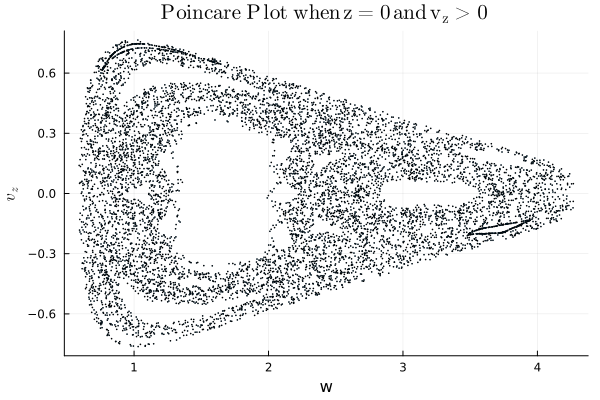

In [38]:
plot(w,vw, seriestype=:scatter,ms=0.5, legend=false)
xlabel!("w")
ylabel!(L"v_z")

# Add a title with LaTeX
title!(latexstring("\\mathrm{Poincare\\, \\, Plot\\, \\, when\\, z=0\\, and\\, v_z>0\\,}"))

In [39]:
function solve_full!(dY,x,p,t)
    """
    Function for solving the system of equation simultaneously with
    the Jacobian

    """
    


    w, z, phi, pw, pz, pphi = @view x[1:6]
    dx = @view x[7:12]
    alpha =  p[1]


    w2 = w^2
    z2 = z^2
    
    wz_sum = w2 + z2
    wz_sum32 = (wz_sum)^(3 / 2)
    wz_sum52 = (wz_sum)^(5 / 2)

    @inbounds begin
    dY[1]  = pw
    dY[2]  = pz
    dY[3]  = L / (mu * w2)

    dY[4] = -mu * (-L^2 / (mu^2 * w^3) + M * w / (wz_sum32))
    dY[5] = -mu * (M * z / (wz_sum32) + alpha * tanh(z / z0))
    dY[6] = 0.0

    # Calculate the derivatives
    dhdwdw = -mu * (3 * L^2 / ((mu^2) * w^4) - 3 * M * w^2 / ((w^2 + z^2)^(5 / 2)) + M / (wz_sum32))
    dhdwdz = 3 * M * mu * w * z / (wz_sum52)
    dhdzdz = -mu * (-3 * M * z^2 / (wz_sum52) + M / (wz_sum32) + alpha / ((cosh(z / z0))^2) / z0)

    dY[7]= dx[4]
    dY[8]= dx[5]
    dY[9] = -2 * L / (mu * w^3) * dx[1] + dx[6] / (mu * w2)
    dY[10] = dhdwdw * dx[1] + dhdwdz * dx[2] + 2 * L *dx[6] / (mu * w^3)
    dY[11] = dhdwdz * dx[1] + dhdzdz * dx[2]

    dY[12]= 0.0


    # J[1, :] = SVector{6}([0.0 0.0 0.0 1.0 0.0 0.0])
    # J[2, :] = SVector{6}([0.0 0.0 0.0 0.0 1.0 0.0])
    # J[3, :] = SVector{6}([-2 * L / (mu * w^3) 0.0 0.0 0.0 0.0 1 / (mu * w^2)])
    # J[4, :] = SVector{6}([dhdwdw dhdwdz 0.0 0.0 0.0 2 * L / (mu * w^3)])
    # J[5, :] = SVector{6}([dhdwdz dhdzdz 0.0 0.0 0.0 0.0])
    # J[6, :] = SVector{6}([0.0 0.0 0.0 0.0 0.0 0.0])


    # dY_dt= J*x[7:12]
    # # mul!(dY[7:12],J,x[7:12])

    # dY[7:12]= dY_dt

    end


    return nothing

end

solve_full! (generic function with 1 method)

In [40]:
dY= zeros(12);
# J= zeros(6,6);

12-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [41]:
rng = MersenneTwister(1234);
w0_ = randn(rng, (6,)) 
w0_ = w0_ / norm(w0_);

In [42]:
ics_0_ = vcat([1.2, 0.0, 0.0, 0.0, 0.76, L],w0_);

In [43]:
ics_0_

12-element Vector{Float64}:
  1.2
  0.0
  0.0
  0.0
  0.76
  1.0
  0.30170125481950066
 -0.31366590006595657
 -0.1720013162874027
 -0.3140730434603041
  0.30067654601238825
  0.7693876404135921

In [44]:
@btime solve_full!(dY,ics_0_,p,0.0);

  977.750 ns (94 allocations: 1.47 KiB)


In [45]:
dY

12-element Vector{Float64}:
  0.0
  0.76
  0.6944444444444444
 -0.1157407407407407
 -0.0
  0.0
 -0.3140730434603041
  0.30067654601238825
  0.18510570535723914
  0.8031971373943483
  0.24425279810691616
  0.0

In [46]:
function renormlize!(integrator)

    idx = Int(round(integrator.t / tau)) 
    @inbounds X1t[idx] = log(norm(@view integrator.u[7:end]))
    rmul!(@view(integrator.u[7:end]),  inv(norm(@view(integrator.u[7:end]))))  # In-place normalization

end

renormlize! (generic function with 1 method)

In [66]:
alpha = 0.1
tau = 1000  #Renormalization time
tf = 1000000.0 #Final time

timestep = range(0.0, tf, step=tau) #* Time interval
size = length(timestep)

X1t = zeros((size - 1)) #*Lyapunaov Exponents
# sum = 0.0

ics= copy(ics_0_)
# usol = zeros(12)

condition(u, t, integrator) = t ∈ timestep
cb = DiscreteCallback(condition, renormlize!; save_positions=(false, false))

DiscreteCallback{typeof(condition), typeof(renormlize!), typeof(SciMLBase.INITIALIZE_DEFAULT), typeof(SciMLBase.FINALIZE_DEFAULT)}(condition, renormlize!, SciMLBase.INITIALIZE_DEFAULT, SciMLBase.FINALIZE_DEFAULT, Bool[0, 0])

In [62]:

prob = ODEProblem(solve_full!, ics, (timestep[1], timestep[end]), [alpha])
@btime usol = solve(prob, reltol=1e-12, abstol=1e-12, maxiters=10000000, callback=cb,dense=false, save_everystep=false, tstops=timestep)
X1t = zeros((size - 1)); #*Lyapunaov Exponents

  1.545 s (128949031 allocations: 1.92 GiB)


5-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0

In [67]:

prob = ODEProblem(solve_full!, ics, (timestep[1], timestep[end]), [alpha])
usol = solve(prob, reltol=1e-12, abstol=1e-12, maxiters=10000000, callback=cb, save_everystep=false,tstops=timestep)

┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase /home/abhishek/.julia/packages/SciMLBase/2HZ5m/src/integrator_interface.jl:576


retcode: MaxIters
Interpolation: 1st order linear
t: 2-element Vector{Float64}:
      0.0
 593291.4142777176
u: 2-element Vector{Vector{Float64}}:
 [1.2, 0.0, 0.0, 0.0, 0.76, 1.0, 0.30170125481950066, -0.31366590006595657, -0.1720013162874027, -0.3140730434603041, 0.30067654601238825, 0.7693876404135921]
 [3.3061066556253675, -0.4104557000674618, 205335.70405587746, -0.14756883117058006, -0.24893568119216816, 1.0, 10.656369232263655, -22.61221943791279, -11.976690478255371, 0.3960479582342485, 9.553082829445628, 0.0]

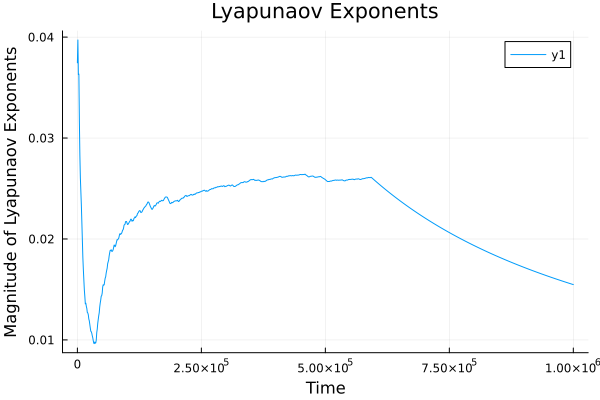

In [68]:
plot(range(0, tf, length=length(timestep[2:end])), cumsum(X1t) ./ timestep[2:end],
    title="Lyapunaov Exponents",
    xlabel="Time",
    ylabel="Magnitude of Lyapunaov Exponents")

In [ ]:
X1t ./ timestep[2:end]

In [ ]:
function get_lyap!(X1t,ics, tau, tf, alpha, steps)

    # ti = 0.0  #* Initial Time
    timestep = range(0.0, tf, step=tau) #* Time interval
    size = length(timestep)

    # X1t = zeros((size - 1)) #*Lyapunaov Exponents
    sum = 0.0
    # J= zeros(6,6)
    # ics = copy(ics0)  #*We do not want to change our initial conditions
    # h = zeros(size - 1) #*Check for energy
    # sol = @SVector zeros((size, 6))
    # sol[1, :] = @view ics[1:6]

    usol= zeros(12)

    
    


    for i in 1:size-1
        # timeint = range(timestep[i], stop=timestep[i+1], length=steps)  # Our time interval with 10000 points between them

        prob = ODEProblem(solve_full!, ics, (timestep[i], timestep[i+1]), [alpha,J])
        usol = solve(prob, reltol=1e-12, abstol=1e-12, maxiters=1000000, saveat=timestep[i+1], save_everystep=false)[end]


        # usol = usol_[end]

        xk = @view usol[1:6]  # Orbit at t = tau
        wk = @view usol[7:end]  # Deviations at t = tau

        # The following algorithm is from the paper
        alphak = norm(wk)
        sum += log(alphak)
        X1t[i] = sum / timestep[i+1]
        # wk ./= alphak

        # # Now for another time step. Set the current solution as the initial conditions for next time steps
        # ics[1:6] .= xk
        # ics[7:end] .= wk

        rmul!(wk, 1 / alphak)  # In-place normalization

        # Update initial conditions for next iteration
        copyto!(ics, usol)

        # sol[i+1, :] .= xk[1:6]
        # println(i)
    end

    return X1t #, sol
    
end

In [ ]:
alpha=10.0
steps= 10000
tau = 1000  #Renormalization time
tf = 1000000.0 #Final time
ics= copy(ics_0_)

println(length(0.0:tau:tf))

X1t = zeros((length(0.0:tau:tf) - 1));

In [ ]:
get_lyap!(X1t,ics,tau,5000.,alpha,steps); #Dry run 
X1t = zeros((length(0.0:tau:tf) - 1));;
ics = copy(ics_0_)

In [ ]:
@time get_lyap!(X1t, ics, tau, 5000.0, alpha, steps)

In [ ]:
@ProfileCanvas.profview get_lyap!(X1t, ics_0_, tau, 5000.0, alpha, steps)

In [ ]:
copyto!(ics,ics_0_)
lyaps1 = get_lyap!(X1t,ics, tau, tf, alpha, steps) #* Lyapunaov Exponents. 

In [ ]:
plot(range(0, tf, length=length(lyaps1)), lyaps1,
    title="Lyapunaov Exponents",
    xlabel="Time",
    ylabel="Magnitude of Lyapunaov Exponents")

# <span style="color: Yellow">Gravitational Wave Forms</span>

In [ ]:
function hplus(t, dH, R, mu,Theta, Psi,alpha )
    """

    Args:
        t ([float]): Time, not needed in this function
        dH ([ndarray]): Solution of differential Equation at various time steps, shape (n,6)
        R ([float]): Distance of observer and the system
        mu ([float]): Mass of the particle
        Theta ([float]): Location of the observer
        Psi ([float]): Location of the observer
        alpha ([float]): Parameter of the theory

    Returns:
        Expression of hplus ([ndarray]) at various time: Shape (n,6)
    """
    # Compute the hplus expression using NumPy

    r,zc,phi,pr,pzc,pphi=dH[:,1],dH[:,2],dH[:,3],dH[:,4],dH[:,5],dH[:,6]

    # Precompute reusable terms
    r2 = r .^ 2
    zc2 = zc .^ 2
    rzc2 = r2 + zc2
    sqrt_rzc2 = rzc2 .^ (3 / 2)
    mu2 = mu^2
    sin_theta2 = sin(Theta)^2
    cos_theta2 = cos(2 * Theta)
    sin_2phi = sin(2 * phi)
    cos_2phi = cos(2 * phi)
    sin_2Psi = sin(2 * Psi)
    cos_2Psi = cos(2 * Psi)
    sin_phi = sin(phi)
    cos_phi = cos(phi)

    dr_dt=pr./mu
    dzc_dt=pzc./mu
    dPhi_dt=L./(mu2 .* r2)
    d2r_dt2 = -(-L .^ 2 ./ (mu .^ 2 .* r .^ 3) + M .* r ./ ((r .^ 2 + zc .^ 2) .^ (3 / 2)))
    d2zc_dt2 = -(M .* zc ./ ((r .^ 2 .+ zc .^ 2) .^ (3 / 2)) .+ alpha .* tanh.(zc ./ z0))
    d2Phi_dt2=0.0

    expression = (1 ./ (2 .* R)) .* mu .* (
        -2 .* sin.(Theta).^2 .* (dr_dt.^2 - 2 .* dzc_dt.^2 .+ r .* d2r_dt2 - 2 .* zc .* d2zc_dt2)
        .+ (3 .+ cos.(2 .* Theta)) .* sin.(2 .* phi) .* (
            sin.(2 .* Psi) .* (dr_dt.^2 .+ r .* (-2 .* r .* dPhi_dt.^2 .+ d2r_dt2))
            - cos.(2 .* Psi) .* r .* (4 .* dr_dt .* dPhi_dt .+ r .* d2Phi_dt2)
        )
        .+ (3 .+ cos.(2 .* Theta)) .* cos.(2 .* phi) .* (
            cos.(2 .* Psi) .* (dr_dt.^2 .+ r .* (-2 .* r .* dPhi_dt.^2 .+ d2r_dt2))
            .+ r .* sin.(2 .* Psi) .* (4 .* dr_dt .* dPhi_dt .+ r .* d2Phi_dt2)
        )
        .+ 2 .* sin.(2 .* Theta) .* sin.(phi) .* (
            -sin.(Psi) .* (2 .* dr_dt .* dzc_dt .+ zc .* d2r_dt2 .+ r .* (-zc .* dPhi_dt.^2 .+ d2zc_dt2))
            .+ cos.(Psi) .* (2 .* (zc .* dr_dt .+ r .* dzc_dt) .* dPhi_dt .+ r .* zc .* d2Phi_dt2)
        )
        - 2 .* cos.(phi) .* sin.(2 .* Theta) .* (
            cos.(Psi) .* (2 .* dr_dt .* dzc_dt .+ zc .* d2r_dt2 .+ r .* (-zc .* dPhi_dt.^2 .+ d2zc_dt2))
            .+ sin.(Psi) .* (2 .* (zc .* dr_dt .+ r .* dzc_dt) .* dPhi_dt .+ r .* zc .* d2Phi_dt2)
        )
    )
    
    return expression
end

In [ ]:
# Define the Python function 'hcross'
function hcross(t, dH, R, mu,Theta, Psi,alpha)
    """

    Args:
        t ([float]): Time, not needed in this function
        dH ([ndarray]): Solution of differential Equation at various time steps, shape (n,6)
        R ([float]): Distance of observer and the system
        mu ([float]): Mass of the particle
        Theta ([float]): Location of the observer
        Psi ([float]): Location of the observer
        alpha ([float]): Parameter of the theory

    Returns:
        Expression of hcross ([ndarray]) at various time: Shape (n,6)
    """
    # Compute the hcross expression using NumPy

    r,zc,phi,pr,pzc,pphi=dH[:,1],dH[:,2],dH[:,3],dH[:,4],dH[:,5],dH[:,6]
    dr_dt=pr
    dzc_dt=pzc
    dPhi_dt=L ./(mu .*r .^2)
    d2r_dt2= .-mu .*(.-L .^2  ./(mu .^2  .* r .^3) + M .*r ./((r .^2+zc .^2) .^(3 /2)))
    d2zc_dt2= .-mu .*(M .*zc ./((r .^2+zc .^2) .^(3 /2))+ alpha .*tanh.(zc ./z0))
    d2Phi_dt2=0.0
    
    # Compute the expression using NumPy
    expression = (1  ./ R)  .* 2  .* mu  .* (
        .-cos.(Theta)  .* sin.(2  .* (Psi .- phi))  .* dr_dt .^2
        + 2  .* dr_dt  .* (sin.(Theta)  .* sin.(Psi .- phi)  .* dzc_dt
                      + (2  .* cos.(Theta)  .* cos.(2  .* (Psi .- phi))  .* r
                         .- cos.(Psi .- phi)  .* sin.(Theta)  .* zc)  .* dPhi_dt)
        + cos.(Theta)  .* r  .* (sin.(2  .* (Psi .- phi))  .* (2  .* r  .* dPhi_dt .^2 .- d2r_dt2)
                              + cos.(2  .* (Psi .- phi))  .* r  .* d2Phi_dt2)
        + sin.(Theta)  .* (sin.(Psi .- phi)  .* zc  .* d2r_dt2
                          .- r  .* (2  .* cos.(Psi .- phi)  .* dzc_dt  .* dPhi_dt
                               + sin.(Psi .- phi)  .* (zc  .* dPhi_dt .^2 .- d2zc_dt2)
                               + cos.(Psi .- phi)  .* zc  .* d2Phi_dt2)))
    
    return expression

end

In [ ]:
Theta = pi / 2
Psi = 0.0
R = 1e10
mu = 1.0

In [ ]:
tm = range(0.0, 500000.0, length=5000000) #Time for integrations
tm2 = range(0.0, 10000.0, length=100000)
t_span = (0, last(tm));

In [ ]:
tm

In [ ]:
ics = [1.2, 0.0, 0.0, 0.0, 0.76, L];
p=[0.1]

In [ ]:
f! = ODEFunction(evolve!, jac=evolve_jac!)
prob = ODEProblem(f!, ics, t_span, p);

In [ ]:
sol = solve(prob, reltol=1e-11, abstol=1e-11, maxiters=1e7,saveat=tm);

In [ ]:
usol01=stack(sol.u,dims=1);

In [ ]:
hp01 = hplus(0, usol01, R, mu, Theta, Psi, alpha); #hplus

In [ ]:
hc01 = hcross(0, usol01, R, mu, Theta, Psi, alpha); #hcross

In [ ]:
plot(tm2, R .* hp01,seriestype=:line, color=:red, ms=0.5, title=L"r$h_+$, $\alpha$=0.1",
    ylabel=L"r$h_+$",
    xlabel="t",
    label=nothing)

In [ ]:
plot(tm2, R .* hc01, seriestype=:line, color=:red, ms=0.5, title=L"r$h_+$, $\alpha$=0.1",
    ylabel=L"r$h_x$",
    xlabel="t",
    label=nothing)

In [ ]:
p=[0.01]

In [ ]:
f! = ODEFunction(evolve!, jac=evolve_jac!)
prob = ODEProblem(f!, ics, t_span, p);

In [ ]:
sol = solve(prob, reltol=1e-11, abstol=1e-11, maxiters=1e7);

In [ ]:
usol001 = stack(sol.u, dims=1);

In [ ]:
hp001 = hplus(0, usol001, R, mu, Theta, Psi, alpha); #hplus
hc001 = hcross(0, usol001, R, mu, Theta, Psi, alpha); #hcross

In [ ]:
plot(tm2, R .* hp001, seriestype=:line, color=:red, ms=0.5, title=L"r$h_+$, $\alpha$=0.01",
    ylabel=L"r$h_+$",
    xlabel="t",
    label=nothing)

In [ ]:
plot(tm2, R .* hc001, seriestype=:line, color=:red, ms=0.5, title=L"r$h_+$, $\alpha$=0.01",
    ylabel=L"r$h_x$",
    xlabel="t",
    label=nothing)

In [ ]:
"""
Calculate dE/dw 

Args:
    t::Vector{Float64}: Time array between which to calculate the FFT
    hp::Vector{Float64}: hplus array
    hc::Vector{Float64}: hcross array

Returns:
    dEdw::Vector{Float64}: dEdw
    df::Vector{Float64}: Fourier Transform Frequencies
"""
function de_dw(t, hp::Vector{Float64}, hc::Vector{Float64})
    # Perform FFT
    fhp = fft(hp) / sqrt(length(hp))  # 'ortho' normalization
    fhc = fft(hc) / sqrt(length(hc))  # 'ortho' normalization
    N = length(fhc)

    dt = t[2] - t[1]
    df = (0:N-1) ./ (dt * N)
    df = df[1:N÷2]

    # Calculate energy
    E = (abs2.(fhp).+abs2.(fhc))[1:N÷2]
    dEdw = E .* df .^ 2 .* R^2

    return dEdw, df
end

In [ ]:
E001, f001 = de_dw(tm2, hp001, hc001)
#* For alpha=0.01

In [ ]:
plot(log10.(f001[2:end]), log10.(E001[2:end]),  # Start from 2 to skip the first element
    seriestype=:line,
    title=L"dE/d$\omega$ vs f for $\alpha=0.01$",
    ylabel=L"$\log_{10}(\frac{dE}{d\omega})$",
    xlabel=L"$\log_{10}f$",
    label=nothing)  # No label, equivalent to not specifying in matplotlib

In [ ]:
E01, f01 = de_dw(tm, hp01, hc01)

In [ ]:
log10.(f01[2:end])

In [ ]:
plot(log10.(f01[2:end]), log10.(E01[2:end]))

In [ ]:
plot(log10.(f01[2:end]), log10.(E01[2:end]),  # Start from 2 to skip the first element
    seriestype=:line,
    title=L"dE/d$\omega$ vs f for $\alpha=0.01$",
    ylabel=L"$\log_{10}(\frac{dE}{d\omega})$",
    xlabel=L"$\log_{10}f$",
    label=nothing)  # No label, equivalent to not specifying in matplotlib